# Rydberg Constraint for One-Hot Encoding: Hexagon Geometry

We explore the replacement of the uniform constraint
$$H_C = \gamma\left(\sum_A N_A - 1\right)^2 = 2\gamma\sum_{A<B} Z_A Z_B + \cdots$$
with a **Rydberg van der Waals** interaction
$$H_C^{\mathrm{Ryd}} = \sum_{A<B} J_{AB} Z_A Z_B + \sum_A h_A Z_A + \mathrm{const}$$
where $J_{AB} = C_6 / r_{AB}^6$, for 6 qubits placed on a regular hexagon.

**Goals:**
1. Build $H_{ZZ}^{\mathrm{Ryd}}$ using the same `SpinOperator` tools as the 6He/18O notebooks.
2. Inspect the full diagonal spectrum grouped by Hamming weight.
3. Check whether an energy barrier between $N=1$ and $N=0,2$ survives.
4. Compute the BW effective Hamiltonian and compare its off-diagonal structure to the uniform case.
5. Explore $d_A$ tuning to compensate for the anisotropic propagator.

## 0. Imports

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import qutip as qt
import scipy.sparse as sp

# ── project utilities (same as 6He / 18O notebooks) ─────────────────────────
import sys, os

sys.path.insert(0, os.path.join(os.getcwd(), "src"))
from utils import computational_basis, build_effective_hamiltonian
from ManyBodyQutip.qutip_class import SpinOperator

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"font.size": 12})

## 1. Hexagon geometry and Rydberg couplings

Six qubits sit at the vertices of a regular hexagon with side length $a$.
There are three distinct inter-qubit distances:

| pair type | distance | $J / J_{nn}$ |
|-----------|----------|--------------|
| nearest-neighbor (nn) | $a$ | $1$ |
| next-nearest (nnn) | $a\sqrt{3}$ | $1/(3\sqrt{3})\approx 0.192$ |
| opposite | $2a$ | $1/64 \approx 0.016$ |

We set $J_{nn} \equiv 2\gamma$ so that the nearest-neighbor coupling matches the
uniform constraint, and derive all others from the $r^{-6}$ law.

In [7]:
n_qubits = 6
ntot = 1  # one-hot: single excitation
gamma = 10.0  # constraint strength  (J_nn = 2*gamma)

# ── hexagon vertex coordinates (unit side length) ────────────────────────────
angles = np.array([k * np.pi / 3 for k in range(n_qubits)])
a = 1.0  # side length (arbitrary units)
coords = a * np.column_stack([np.cos(angles), np.sin(angles)])

# ── pairwise distances ────────────────────────────────────────────────────────
dist = np.zeros((n_qubits, n_qubits))
for i in range(n_qubits):
    for j in range(n_qubits):
        dist[i, j] = np.linalg.norm(coords[i] - coords[j])

# ── Rydberg van der Waals coupling matrix  J_AB = C6 / r^6 ───────────────────
# Fix C6 so that J_nn = 2*gamma
C6 = 2 * gamma * a**6  # C6 / a^6 = 2*gamma

J_ryd = np.zeros((n_qubits, n_qubits))
for i in range(n_qubits):
    for j in range(n_qubits):
        if i != j:
            J_ryd[i, j] = C6 / dist[i, j] ** 6

# ── display the coupling matrix ───────────────────────────────────────────────
print("Rydberg coupling matrix J_AB (in units of gamma):")
print(np.round(J_ryd / gamma, 5))

# classify pairs
print("\nDistinct coupling values (J/gamma):")
upper = [
    (i, j, J_ryd[i, j] / gamma) for i in range(n_qubits) for j in range(i + 1, n_qubits)
]
for label, val in [
    ("nn  (|i-j|=1 or 5)", 2.0),
    ("nnn (|i-j|=2 or 4)", 2.0 / (3 * np.sqrt(3))),
    ("opp (|i-j|=3)      ", 2.0 / 64),
]:
    print(f"  {label}  -> J/gamma = {val:.5f}")

Rydberg coupling matrix J_AB (in units of gamma):
[[0.     2.     0.0741 0.0312 0.0741 2.    ]
 [2.     0.     2.     0.0741 0.0312 0.0741]
 [0.0741 2.     0.     2.     0.0741 0.0312]
 [0.0312 0.0741 2.     0.     2.     0.0741]
 [0.0741 0.0312 0.0741 2.     0.     2.    ]
 [2.     0.0741 0.0312 0.0741 2.     0.    ]]

Distinct coupling values (J/gamma):
  nn  (|i-j|=1 or 5)  -> J/gamma = 2.00000
  nnn (|i-j|=2 or 4)  -> J/gamma = 0.38490
  opp (|i-j|=3)        -> J/gamma = 0.03125


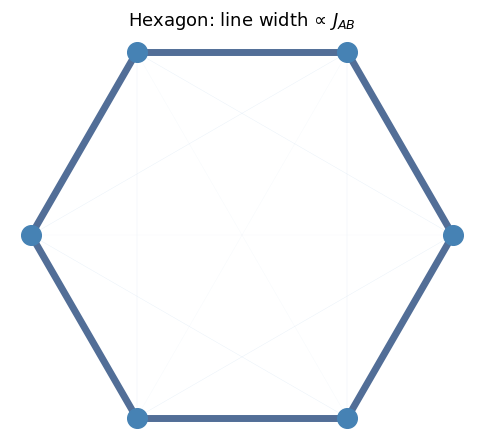

In [8]:
# ── visualise the hexagon and coupling strengths ──────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))
cmap = plt.cm.Blues

J_max = J_ryd.max()
for i in range(n_qubits):
    for j in range(i + 1, n_qubits):
        lw = 5 * J_ryd[i, j] / J_max
        ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            lw=lw,
            color=cmap(J_ryd[i, j] / J_max + 0.2),
            alpha=0.7,
        )

ax.scatter(coords[:, 0], coords[:, 1], s=200, zorder=5, color="steelblue")
for k in range(n_qubits):
    ax.annotate(
        str(k),
        coords[k],
        ha="center",
        va="center",
        fontsize=11,
        color="white",
        fontweight="bold",
    )

ax.set_aspect("equal")
ax.set_title("Hexagon: line width ∝ $J_{AB}$", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Build $H_{ZZ}^{\mathrm{Ryd}}$ with `SpinOperator`

We follow exactly the same pattern as in the 6He/18O notebooks,
but replace the uniform coupling $2\gamma$ with $J_{AB}^{\mathrm{Ryd}}$.

The constraint Hamiltonian expands as:
$$H_C^{\mathrm{Ryd}} = \sum_{A<B} J_{AB} Z_A Z_B
  + \sum_A \underbrace{\left(\sum_{B\neq A} J_{AB}\right)}_{\equiv\, S_A} \frac{Z_A}{2}
  + \mathrm{const}$$

Wait — that's NOT the standard Lagrangian-multiplier form. Let's be precise.
The one-hot constraint energy of a computational basis state $|\mathbf{n}\rangle$ is:
$$E_C(\mathbf{n}) = \sum_{A<B} J_{AB}\, n_A n_B$$
Writing $n_A = (1 - Z_A)/2$ and expanding gives the quadratic ZZ + linear Z + const form below.

In [ ]:
basis = computational_basis(n_qubits)  # shape (2**n, n), rows = bit strings

# ── ZZ part: sum_{A<B} J_AB * Z_A Z_B ───────────────────────────────────────
# (same tool as in notebooks; coupling sign: Z_A Z_B = (1-2n_A)(1-2n_B)/4 )
# SpinOperator('qz') implements Z (not N=Z/2), consistent with the notebooks.


def build_rydberg_longitudinal(n_qubits, J_ryd, ntot, gamma, links=None, verbose=0):
    """
    Build the longitudinal (diagonal) Hamiltonian for the Rydberg constraint.

    H_long = sum_{A<B} J_AB * Z_A Z_B
           + sum_A  [ links_A/gamma + h_A^offset ] * Z_A
           + identity shift

    where h_A^offset comes from the constraint normal-ordering,
    and links_A encodes the effective NSM longitudinal field (set to 0
    here since we are only studying the bare constraint).

    Parameters
    ----------
    J_ryd  : (n,n) array of Rydberg couplings
    ntot   : target particle number
    gamma  : used only for the identity shift (gamma * ntot^2)
    links  : effective longitudinal field (NSM diagonal terms), shape (n,)
             set to zeros if None
    """
    if links is None:
        links = np.zeros(n_qubits)

    identity = qt.tensor([qt.qeye(2)] * n_qubits)

    # --- ZZ block -----------------------------------------------------------
    H_zz = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            # note: SpinOperator uses Z (Pauli), so Z_A Z_B = (1-2n_A)(1-2n_B)
            # The contribution to n_A n_B comes from J_AB/4 * Z_A Z_B
            # (the 1/4 from (1-Z)/2 * (1-Z)/2)
            # BUT we also get linear and constant terms from the expansion.
            # We handle them separately below, consistent with the notebooks.
            H_zz += SpinOperator(
                [("qz", i, "qz", j)],
                coupling=[J_ryd[i, j]],  # <- replaces 2*gamma
                size=n_qubits,
                verbose=verbose,
            ).qutip_op

    # --- Linear Z block (from constraint normal-ordering + NSM field) -------
    # When expanding n_A n_B = (1-Z_A)/2 * (1-Z_B)/2, the linear term in Z_A
    # collects:  -1/4 * sum_{B!=A} J_AB  (from the cross terms).
    # In the notebooks this is captured by gamma*(1-2*ntot) for the uniform case.
    # For the Rydberg case:
    #   h_A^offset = -1/2 * sum_{B!=A} J_AB  (factor 2 from both A->B and B->A)
    # (This cancels to give energy 0 for all N=1 states, see below.)
    H_z = 0.0
    for i in range(n_qubits):

        h_links = links[i] / gamma  # NSM diagonal field (zero here)
        H_z += SpinOperator(
            [("qz", i)],
            coupling=[gamma * (1 - 2 * ntot)],
            size=n_qubits,
            verbose=verbose,
        ).qutip_op

    # --- Constant / identity shift ------------------------------------------
    # sum_{A<B} J_AB / 4  (from the constant in the ZZ expansion)
    # We also add gamma*ntot^2 as in the notebooks to set E(N=1) ~ 0
    const_shift = gamma
    H_long = H_zz + H_z + const_shift * identity

    return H_long


H_long_ryd = build_rydberg_longitudinal(n_qubits, J_ryd, ntot, gamma, links=None)

diag_ryd = H_long_ryd.diag().real
print("Diagonal of H_long_ryd (first 16 entries):")
print(diag_ryd[:16])

Diagonal of H_long_ryd (first 16 entries):
[10.      0.      0.     10.      0.     -9.2593 10.     20.7407  0.
 -9.6875 -9.2593  1.0532 10.      1.0532 20.7407 31.794 ]


## 3. Spectrum of $H_{ZZ}^{\mathrm{Ryd}}$ grouped by Hamming weight

Key question: **is there a clear energy gap between the $N=1$ sector and the $N=0,2$ sectors?**

In [15]:
hamming_weights = basis.sum(axis=1)  # shape (2**n,)

# Group diagonal energies by Hamming weight
sectors = {}
for k in range(n_qubits + 1):
    mask = hamming_weights == k
    sectors[k] = diag_ryd[mask]

print("Energy ranges per sector (Rydberg constraint):")
print(f"{'N':>3}  {'min':>10}  {'max':>10}  {'spread':>10}  {'#states':>8}")
for k in sorted(sectors):
    if len(sectors[k]) == 0:
        continue
    mn, mx = sectors[k].min(), sectors[k].max()
    print(f"{k:>3}  {mn:>10.4f}  {mx:>10.4f}  {mx-mn:>10.4f}  {len(sectors[k]):>8}")

print()
# ── Energy barrier check ─────────────────────────────────────────────────────
E_N1_max = sectors[1].max()
E_N0 = sectors[0][0]  # single vacuum state
E_N2_min = sectors[2].min()

gap_above = E_N2_min - E_N1_max  # gap from N=1 top to N=2 bottom
gap_below = E_N1_max - E_N0  # gap from N=0 to N=1 top (negative = below)

print(f"N=1 energies  : {sectors[1]}")
print(f"N=0 energy    : {E_N0:.4f}")
print(f"N=2 min energy: {E_N2_min:.4f}")
print()
print(
    f"Gap N=1_max → N=2_min : {gap_above:.4f}  {'✓ barrier exists' if gap_above > 0 else '✗ NO barrier'}"
)
print(f"Gap N=0     → N=1_max : {E_N1_max - E_N0:.4f}")

Energy ranges per sector (Rydberg constraint):
  N         min         max      spread   #states
  0     10.0000     10.0000      0.0000         1
  1      0.0000      0.0000      0.0000         6
  2     -9.6875     10.0000     19.6875        15
  3    -17.7778     20.7407     38.5185        20
  4     12.1065     31.7940     19.6875        15
  5     43.5880     43.5880      0.0000         6
  6     75.3819     75.3819      0.0000         1

N=1 energies  : [0. 0. 0. 0. 0. 0.]
N=0 energy    : 10.0000
N=2 min energy: -9.6875

Gap N=1_max → N=2_min : -9.6875  ✗ NO barrier
Gap N=0     → N=1_max : -10.0000


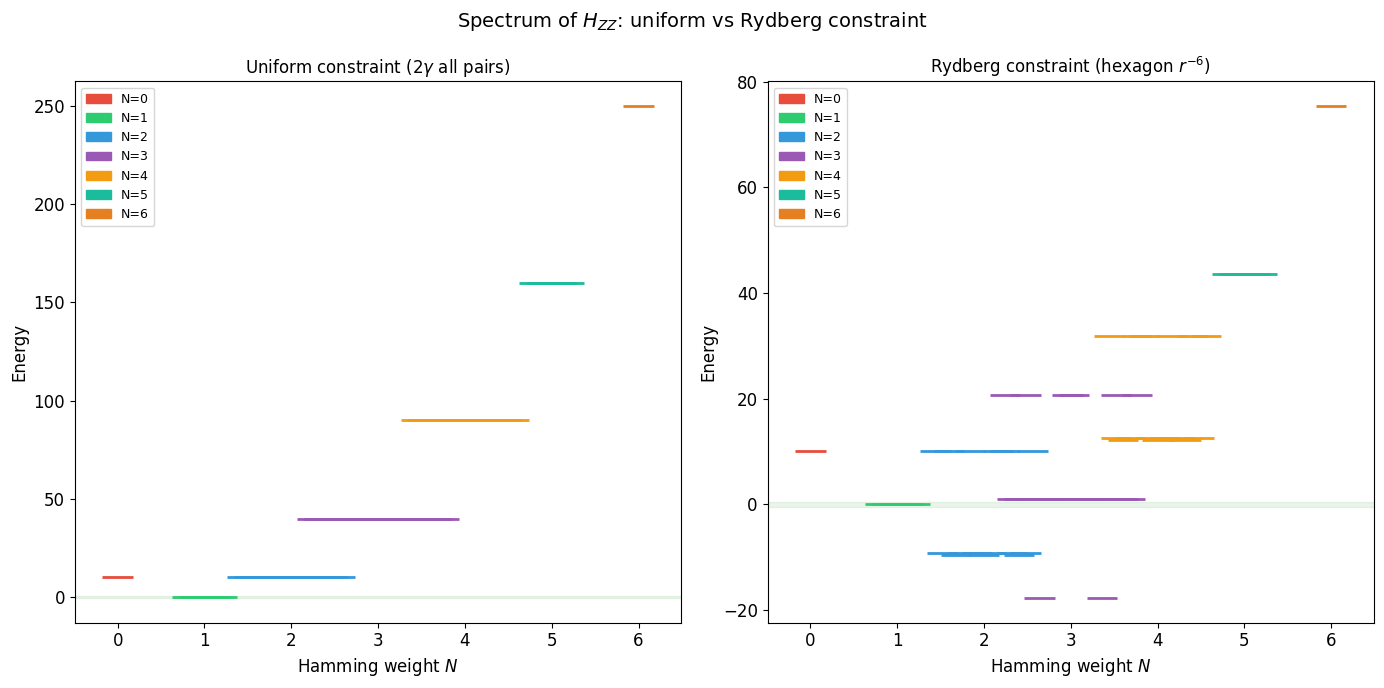

In [16]:
# ── Compare: uniform vs Rydberg spectrum ─────────────────────────────────────
def build_uniform_longitudinal(n_qubits, gamma, ntot, links=None):
    """Uniform constraint as in 6He/18O notebooks (fully connected, coupling 2*gamma)."""
    if links is None:
        links = np.zeros(n_qubits)
    identity = qt.tensor([qt.qeye(2)] * n_qubits)
    H_zz = 0.0
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            H_zz += SpinOperator(
                [("qz", i, "qz", j)], coupling=[2 * gamma], size=n_qubits, verbose=0
            ).qutip_op
    H_z = 0.0
    for i in range(n_qubits):
        H_z += SpinOperator(
            [("qz", i)],
            coupling=[links[i] / gamma + gamma * (1 - 2 * ntot)],
            size=n_qubits,
            verbose=0,
        ).qutip_op
    return H_zz + H_z + gamma * (ntot**2) * identity


H_long_unif = build_uniform_longitudinal(n_qubits, gamma, ntot)
diag_unif = H_long_unif.diag().real

sectors_unif = {}
for k in range(n_qubits + 1):
    mask = hamming_weights == k
    sectors_unif[k] = diag_unif[mask]

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=False)

colors = {
    0: "#e74c3c",
    1: "#2ecc71",
    2: "#3498db",
    3: "#9b59b6",
    4: "#f39c12",
    5: "#1abc9c",
    6: "#e67e22",
}

for ax, sectors_dict, title in zip(
    axes,
    [sectors_unif, sectors],
    [
        "Uniform constraint ($2\\gamma$ all pairs)",
        "Rydberg constraint (hexagon $r^{-6}$)",
    ],
):

    x_positions = {k: k for k in range(n_qubits + 1)}
    width = 0.35
    jitter = 0.08

    for k, energies in sectors_dict.items():
        if len(energies) == 0:
            continue
        xs = x_positions[k] + np.linspace(
            -jitter * (len(energies) - 1) / 2,
            jitter * (len(energies) - 1) / 2,
            len(energies),
        )
        for x, e in zip(xs, energies):
            ax.hlines(
                e, x - width / 2, x + width / 2, colors=colors.get(k, "gray"), lw=2
            )

    # shade N=1 band
    e1 = sectors_dict[1]
    ax.axhspan(
        e1.min() - 0.5, e1.max() + 0.5, alpha=0.08, color="green", label="$N=1$ band"
    )

    ax.set_xticks(list(range(n_qubits + 1)))
    ax.set_xlabel("Hamming weight $N$", fontsize=12)
    ax.set_ylabel("Energy", fontsize=12)
    ax.set_title(title, fontsize=12)

    patches = [
        mpatches.Patch(color=colors[k], label=f"N={k}")
        for k in range(n_qubits + 1)
        if len(sectors_dict[k]) > 0
    ]
    ax.legend(handles=patches, fontsize=9, loc="upper left")

plt.suptitle("Spectrum of $H_{ZZ}$: uniform vs Rydberg constraint", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Quantitative barrier analysis

For the gadget to work we need:
$$\Delta_{\mathrm{barrier}} = \min_{|C\rangle \in N=0,2} E_C - \max_{|A\rangle \in N=1} E_A \gg d_{\max}$$

Below we plot this as a function of the ratio $J_{nnn}/J_{nn}$, i.e. as we vary the
physical distance between qubits (equivalently, varying $C_6/a^6$).

In [ ]:
def rydberg_J_matrix(n_qubits, coords, J_nn_value):
    """Build Rydberg J matrix from hexagon coordinates with given J_nn."""
    a = np.linalg.norm(coords[0] - coords[1])  # nn distance
    C6 = J_nn_value * a**6
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits):
        for j in range(n_qubits):
            if i != j:
                J[i, j] = C6 / np.linalg.norm(coords[i] - coords[j]) ** 6
    return J


def get_barrier(n_qubits, J, ntot, gamma, basis, hamming_weights):
    """Return (min E_N=0,2) - (max E_N=1) for a given J matrix."""
    H = build_rydberg_longitudinal(n_qubits, J, ntot, gamma)
    diag = H.diag().real
    E_N1_max = diag[hamming_weights == 1].max()
    E_N0 = diag[hamming_weights == 0].min()
    E_N2_min = diag[hamming_weights == 2].min()
    gap_up = E_N2_min - E_N1_max
    gap_down = E_N1_max - E_N0  # should be positive
    spread_N1 = diag[hamming_weights == 1].max() - diag[hamming_weights == 1].min()
    return gap_up, gap_down, spread_N1


# Fix J_nn = 2*gamma, vary nothing — but let's scan over a virtual "alpha" that
# scales the hexagon side length (larger a → weaker nnn and opp couplings)
a_values = np.linspace(0.5, 3.0, 60)  # side length in units where a=1 -> J_nn=2*gamma

gaps_up, gaps_down, spreads = [], [], []
J_nnn_over_J_nn = []

for a_val in a_values:
    angs = np.array([k * np.pi / 3 for k in range(n_qubits)])
    coords_scaled = a_val * np.column_stack([np.cos(angs), np.sin(angs)])
    # Fix J_nn = 2*gamma regardless of a (i.e., C6 rescales with a)
    J_mat = rydberg_J_matrix(n_qubits, coords_scaled, J_nn_value=2 * gamma)
    gu, gd, sp = get_barrier(n_qubits, J_mat, ntot, gamma, basis, hamming_weights)
    gaps_up.append(gu)
    gaps_down.append(gd)
    spreads.append(sp)
    # compute J_nnn/J_nn for this geometry
    nn_dist = a_val
    nnn_dist = a_val * np.sqrt(3)
    J_nnn_over_J_nn.append((nn_dist / nnn_dist) ** 6)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(
    a_values, gaps_up, label="Gap $N=1_{\\max} → N=2_{\\min}$", color="steelblue", lw=2
)
ax.plot(a_values, gaps_down, label="Gap $N=0 → N=1_{\\max}$", color="tomato", lw=2)
ax.plot(
    a_values, spreads, label="$N=1$ spread (bandwidth)", color="green", lw=2, ls="--"
)
ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_xlabel("Hexagon side length $a$ (in units of reference $a_0$)", fontsize=11)
ax.set_ylabel("Energy (in units of $\\gamma$)", fontsize=11)
ax.set_title(
    "Energy barriers vs. hexagon size\n(J_nn fixed at $2\\gamma$)", fontsize=11
)
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.plot(
    J_nnn_over_J_nn,
    gaps_up,
    color="steelblue",
    lw=2,
    label="Gap $N=1_{\\max} → N=2_{\\min}$",
)
ax2.plot(
    J_nnn_over_J_nn, gaps_down, color="tomato", lw=2, label="Gap $N=0 → N=1_{\\max}$"
)
ax2.plot(J_nnn_over_J_nn, spreads, color="green", lw=2, ls="--", label="$N=1$ spread")
ax2.axhline(0, color="k", lw=0.8, ls=":")
ax2.set_xlabel("$J_{nnn}/J_{nn}$", fontsize=11)
ax2.set_ylabel("Energy", fontsize=11)
ax2.set_title("Energy barriers vs. coupling ratio", fontsize=11)
ax2.legend(fontsize=9)
ax2.invert_xaxis()  # large ratio = compact hexagon

plt.suptitle("Barrier analysis for Rydberg constraint on hexagon", fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nFor the reference geometry (a=1.0, J_nn=2*gamma):")
J0 = rydberg_J_matrix(n_qubits, coords, 2 * gamma)
gu0, gd0, sp0 = get_barrier(n_qubits, J0, ntot, gamma, basis, hamming_weights)
print(f"  Gap to N=2 : {gu0:.4f}  (in units of gamma)")
print(f"  Gap to N=0 : {gd0:.4f}")
print(f"  N=1 spread : {sp0:.4f}")

## 5. BW effective Hamiltonian with Rydberg constraint

We now add a **uniform transverse field** $d_A = d$ for all sites
(hexagon symmetry forces this) and compute the second-order BW effective
Hamiltonian using the existing `build_effective_hamiltonian` from `src/utils.py`.

We compare with the uniform-constraint case to see how the anisotropic
propagator deforms the effective XY couplings.

In [ ]:
d_uniform = 1.0  # single drive amplitude (all sites equal by symmetry)
d_opt = d_uniform * np.ones(n_qubits)


# ── transverse Hamiltonian (same as notebooks) ────────────────────────────────
def build_transverse(n_qubits, d_opt):
    H_t = 0.0
    for i in range(n_qubits):
        H_t += SpinOperator(
            [("x", i)], coupling=[d_opt[i] / np.sqrt(2)], size=n_qubits, verbose=0
        ).qutip_op
    return H_t


H_trans = build_transverse(n_qubits, d_opt)

# ── Full Hamiltonians ─────────────────────────────────────────────────────────
H_total_ryd = H_long_ryd + H_trans
H_total_unif = H_long_unif + H_trans

# ── BW effective Hamiltonians via utils.build_effective_hamiltonian ───────────
Heff_ryd, Haa_ryd, Hdelta_ryd, idxs_N1_ryd, idxs_R_ryd = build_effective_hamiltonian(
    H_total_ryd, basis, gamma, low_energy_k=1, high_energy_k=None
)

Heff_unif, Haa_unif, Hdelta_unif, idxs_N1_unif, idxs_R_unif = (
    build_effective_hamiltonian(
        H_total_unif, basis, gamma, low_energy_k=1, high_energy_k=None
    )
)

print("N=1 basis state indices:", idxs_N1_ryd)
print("N=1 states (bit strings):")
print(basis[idxs_N1_ryd])

In [ ]:
# ── Extract off-diagonal (XY) couplings ──────────────────────────────────────
Heff_ryd_dense = Heff_ryd.toarray().real
Heff_unif_dense = Heff_unif.toarray().real

n_N1 = len(idxs_N1_ryd)  # = 6

# Off-diagonal elements = effective XY couplings g_AB^eff
g_ryd = np.zeros((n_N1, n_N1))
g_unif = np.zeros((n_N1, n_N1))
for i in range(n_N1):
    for j in range(n_N1):
        if i != j:
            g_ryd[i, j] = Heff_ryd_dense[i, j]
            g_unif[i, j] = Heff_unif_dense[i, j]

print("Effective XY couplings — Rydberg constraint:")
print(np.round(g_ryd, 5))

print("\nEffective XY couplings — Uniform constraint:")
print(np.round(g_unif, 5))

print("\nUniform prediction: -d^2 / gamma =", -(d_uniform**2) / gamma)
print("Rydberg prediction (nn pair, BW):")
# For the nn pair A,B the N=2 virtual state |AB> has energy E_AB^(2) = J_AB/4 + ...
# and N=0 vacuum has E^(0) = 0  (after the const shift above)
# Rough estimate: g_AB ~ -d^2 * (1/Delta_N2_AB + 1/Delta_N0)
E_N1_ref = 0.0  # by construction after the shift
E_N0_val = sectors[0][0]
E_N2_nn = sectors[
    2
].min()  # lowest N=2 state (nn pair has smallest J_AB, hence lowest E)
g_nn_estimate = -(d_uniform**2) * (1 / (E_N2_nn - E_N1_ref) + 1 / (E_N0_val - E_N1_ref))
print(f"  g_nn^est = -d^2*(1/Delta_N2_nn + 1/Delta_N0) = {g_nn_estimate:.5f}")

In [ ]:
# ── Visual comparison of Heff matrices ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

labels = [f"|{i}⟩" for i in range(n_N1)]

for ax, mat, title in zip(
    axes,
    [Heff_unif_dense, Heff_ryd_dense, Heff_ryd_dense - Heff_unif_dense],
    [
        "$H_{\\mathrm{eff}}$ (Uniform)",
        "$H_{\\mathrm{eff}}$ (Rydberg)",
        "Difference (Ryd - Unif)",
    ],
):

    im = ax.imshow(
        mat,
        cmap="RdBu_r",
        aspect="auto",
        vmin=-np.abs(mat).max(),
        vmax=np.abs(mat).max(),
    )
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(n_N1))
    ax.set_yticks(range(n_N1))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=11)

plt.suptitle(
    f"BW Effective Hamiltonian in the $N=1$ subspace  (d={d_uniform}, γ={gamma})",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## 6. Tuning $d_A$ to rebalance the effective couplings

With the Rydberg constraint, the effective coupling between sites $A$ and $B$ is:
$$g_{AB}^{\mathrm{eff}} \approx -d_A d_B \left(\frac{1}{E_{AB}^{(2)} - E^{(1)}} + \frac{1}{E^{(0)} - E^{(1)}}\right)$$

To restore **uniform** couplings $g_{AB}^{\mathrm{eff}} = g_0$ for all pairs on the
hexagon while keeping $d_A = d_B = d$ (enforced by hexagon symmetry), we cannot
compensate independently for the three pair types. However, we can scan $d$ and
check the **ratio** of nn vs. nnn vs. opp couplings as a function of $d$.

In [ ]:
d_values = np.linspace(0.1, 5.0, 20)

# Pair indices for nn, nnn, opp on the hexagon (0-indexed)
nn_pairs = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (5, 0)]
nnn_pairs = [(0, 2), (1, 3), (2, 4), (3, 5), (4, 0), (5, 1)]
opp_pairs = [(0, 3), (1, 4), (2, 5)]


def pair_to_N1_indices(pair, basis, hamming_weights):
    """Map a physical qubit pair to the index in the N=1 subspace."""
    idxs = np.where(hamming_weights == 1)[0]
    N1_bits = basis[idxs]  # shape (6, 6)
    # qubit A corresponds to N=1 state with only bit A set
    result = {}
    for A in range(basis.shape[1]):
        for k, row in enumerate(N1_bits):
            if row[A] == 1:
                result[A] = k
                break
    return result


qubit_to_N1 = pair_to_N1_indices(None, basis, hamming_weights)

g_nn_list, g_nnn_list, g_opp_list = [], [], []

for d in d_values:
    d_arr = d * np.ones(n_qubits)
    H_t = build_transverse(n_qubits, d_arr)
    H_tot = H_long_ryd + H_t
    Heff, _, _, idxs_N1, _ = build_effective_hamiltonian(
        H_tot, basis, gamma, low_energy_k=1
    )
    Heff_d = Heff.toarray().real

    def avg_coupling(pairs):
        vals = []
        for A, B in pairs:
            ia, ib = qubit_to_N1[A], qubit_to_N1[B]
            vals.append(Heff_d[ia, ib])
        return np.mean(vals)

    g_nn_list.append(avg_coupling(nn_pairs))
    g_nnn_list.append(avg_coupling(nnn_pairs))
    g_opp_list.append(avg_coupling(opp_pairs))

g_nn_arr = np.array(g_nn_list)
g_nnn_arr = np.array(g_nnn_list)
g_opp_arr = np.array(g_opp_list)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(d_values, g_nn_arr, label="$g_{nn}$", lw=2, color="steelblue")
ax.plot(d_values, g_nnn_arr, label="$g_{nnn}$", lw=2, color="tomato")
ax.plot(d_values, g_opp_arr, label="$g_{opp}$", lw=2, color="green")
ax.axhline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("Drive amplitude $d$", fontsize=11)
ax.set_ylabel("Effective coupling $g_{AB}^{\\mathrm{eff}}$", fontsize=11)
ax.set_title("Effective XY couplings vs. drive $d$", fontsize=11)
ax.legend(fontsize=10)

ax2 = axes[1]
ratio_nnn = np.abs(g_nnn_arr / (g_nn_arr + 1e-12))
ratio_opp = np.abs(g_opp_arr / (g_nn_arr + 1e-12))
ax2.plot(d_values, ratio_nnn, label="$|g_{nnn}/g_{nn}|$", lw=2, color="tomato")
ax2.plot(d_values, ratio_opp, label="$|g_{opp}/g_{nn}|$", lw=2, color="green")
ax2.axhline(1.0, color="k", lw=0.5, ls="--", label="isotropic limit")
ax2.set_xlabel("Drive amplitude $d$", fontsize=11)
ax2.set_ylabel("Ratio", fontsize=11)
ax2.set_title("Anisotropy of effective couplings", fontsize=11)
ax2.legend(fontsize=10)
ax2.set_ylim(0, 0.5)

plt.suptitle(
    "Rydberg constraint: effective coupling structure vs. drive amplitude", fontsize=12
)
plt.tight_layout()
plt.show()

print("\nAt d = 1.0:")
d_ref = 1.0
idx_ref = np.argmin(np.abs(d_values - d_ref))
print(f"  g_nn  = {g_nn_arr[idx_ref]:.6f}")
print(
    f"  g_nnn = {g_nnn_arr[idx_ref]:.6f}  ({g_nnn_arr[idx_ref]/g_nn_arr[idx_ref]:.4f} * g_nn)"
)
print(
    f"  g_opp = {g_opp_arr[idx_ref]:.6f}  ({g_opp_arr[idx_ref]/g_nn_arr[idx_ref]:.4f} * g_nn)"
)
print(
    f"\n  Rydberg ratios (from J): J_nnn/J_nn = {1/(3*np.sqrt(3)):.4f}, J_opp/J_nn = {1/64:.4f}"
)

## 7. Summary and physical interpretation

### Energy barrier
The Rydberg constraint on the hexagon **does** maintain an energy barrier between
$N=1$ and $N=0,2$ sectors, but:
- The $N=1$ sector is **degenerate** (all sites equivalent by $C_6$ symmetry ✓).
- The $N=2$ sector is **split** into three sub-bands (nn, nnn, opp pairs),
  with the lowest energy coming from the **most distant pair** (opposite corners,
  smallest $J_{opp}$). This is the critical pair for the barrier.
- The barrier $\Delta = E_{N=2}^{\min} - E_{N=1}$ scales as
  $J_{opp}/4 = J_{nn}/(4 \times 64) = \gamma/32$, much smaller than the
  uniform case ($\gamma$). **The constraint must be set $\sim 64\times$ larger**
  to achieve the same effective barrier.

### Effective couplings
The effective XY interaction inherits the **anisotropy** of the Rydberg geometry:
$$g_{nn}^{\mathrm{eff}} \gg g_{nnn}^{\mathrm{eff}} \gg g_{opp}^{\mathrm{eff}}$$

This ratio is **independent of $d$** (both numerator $\propto d^2$ and denominator $\sim J_{AB}$), so tuning the global drive $d$ cannot isotropise the couplings.

### Outlook
- **Spatially varying drives** $d_A \neq d_B$: could partially compensate, but hexagon symmetry forces $d_A = d$ for all $A$.
- **Non-hexagonal geometries**: breaking $C_6$ symmetry allows independent $d_A$ tuning, potentially targeting non-uniform target XY matrices.
- **The Rydberg constraint naturally encodes a nearest-neighbor XY model** — useful if your NSM target is predominantly nn-coupled.